In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
plt.style.use("seaborn-v0_8-pastel")
pd.set_option("display.max_columns", None)

### Load Dataset

In [2]:
df = pd.read_csv("../data/processed/historical_f1_data.csv")
df.head()

,race_id,year,round,race_date,race_name,circuit_id,driver_id,driver_code,driver_name,constructor_id,constructor_name,grid_position,finish_position,points,status_id,quali_position,winner
0,989,2018,1,2018-03-25,Australian Grand Prix,albert_park,20,vettel,Vettel,6,Ferrari,3,1,25.0,1,3.0,1
1,989,2018,1,2018-03-25,Australian Grand Prix,albert_park,1,hamilton,Hamilton,131,Mercedes,1,2,18.0,1,1.0,0
2,989,2018,1,2018-03-25,Australian Grand Prix,albert_park,8,raikkonen,Räikkönen,6,Ferrari,2,3,15.0,1,2.0,0
3,989,2018,1,2018-03-25,Australian Grand Prix,albert_park,817,ricciardo,Ricciardo,9,Red Bull,8,4,12.0,1,5.0,0
4,989,2018,1,2018-03-25,Australian Grand Prix,albert_park,4,alonso,Alonso,1,McLaren,10,5,10.0,1,11.0,0


### Dataset Overview

In [3]:
print("Dataset Shape:", df.shape) 
print("\nColumns:") 
print(df.columns) 
print("\nMissing Values:") 
print(df.isnull().sum())

Dataset Shape: (2976, 17)

Columns:
Index(['race_id', 'year', 'round', 'race_date', 'race_name', 'circuit_id',
       'driver_id', 'driver_code', 'driver_name', 'constructor_id',
       'constructor_name', 'grid_position', 'finish_position', 'points',
       'status_id', 'quali_position', 'winner'],
      dtype='object')

Missing Values:
race_id             0
year                0
round               0
race_date           0
race_name           0
circuit_id          0
driver_id           0
driver_code         0
driver_name         0
constructor_id      0
constructor_name    0
grid_position       0
finish_position     0
points              0
status_id           0
quali_position      0
winner              0
dtype: int64


In [4]:
df.describe()

,race_id,year,round,driver_id,constructor_id,grid_position,finish_position,points,status_id,quali_position,winner
count,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000,2976.00000,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000
mean,1066.255712,2021.107863,11.245296,694.727151,81.174395,10.06082,10.492944,5.077453,9.084005,10.487567,0.050067
std,45.808973,2.030720,6.283309,309.368187,88.017532,5.81554,5.766255,7.223768,21.301793,5.761114,0.218120
min,989.000000,2018.000000,1.000000,1.000000,1.000000,0.00000,1.000000,0.000000,1.000000,1.000000,0.000000
25%,1026.000000,2019.000000,6.000000,815.000000,5.000000,5.00000,5.000000,0.000000,1.000000,5.000000,0.000000
50%,1066.000000,2021.000000,11.000000,832.000000,15.000000,10.00000,10.000000,0.750000,1.000000,10.000000,0.000000
75%,1107.000000,2023.000000,16.000000,846.000000,210.000000,15.00000,15.000000,9.000000,11.000000,15.000000,0.000000
max,1144.000000,2024.000000,24.000000,862.000000,215.000000,20.00000,20.000000,26.000000,141.000000,20.000000,1.000000


In [5]:
df.dtypes

race_id               int64
year                  int64
round                 int64
race_date            object
race_name            object
circuit_id           object
driver_id             int64
driver_code          object
driver_name          object
constructor_id        int64
constructor_name     object
grid_position         int64
finish_position       int64
points              float64
status_id             int64
quali_position      float64
winner                int64
dtype: object

### Class Imbalance

winner
0    2827
1     149
Name: count, dtype: int64


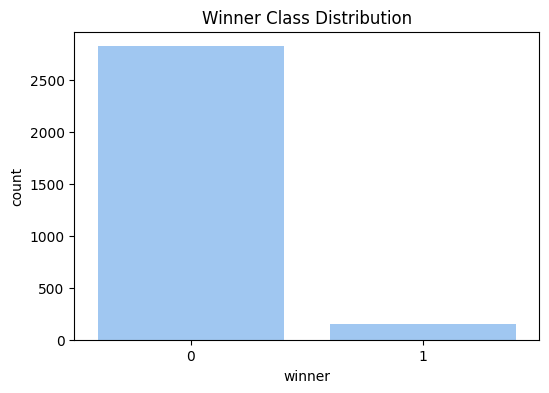

In [6]:
print(df['winner'].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(data = df, x='winner')
plt.title("Winner Class Distribution")
plt.show()

### Grid Position vs Winning

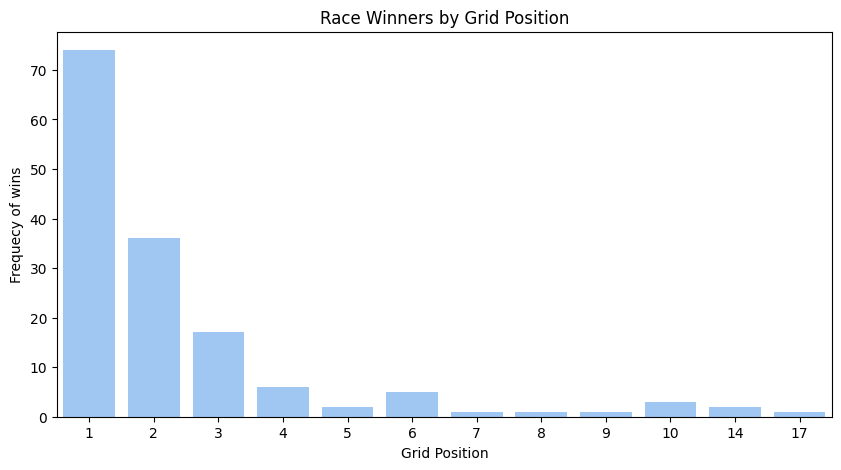

In [7]:
winners = df[df['winner'] == 1]
grid_win_count = winners['grid_position'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.barplot(x=grid_win_count.index, y=grid_win_count.values)
plt.title("Race Winners by Grid Position")
plt.xlabel("Grid Position")
plt.ylabel("Frequecy of wins")
plt.show()

### Pole Position Win Rate

In [8]:
pole = df[df['grid_position']==1]
pole_wins = pole['winner'].sum()
winning_rate = (pole_wins/len(pole)) * 100
print(f"Winning Rate : {winning_rate:.2f}")

Winning Rate : 49.66


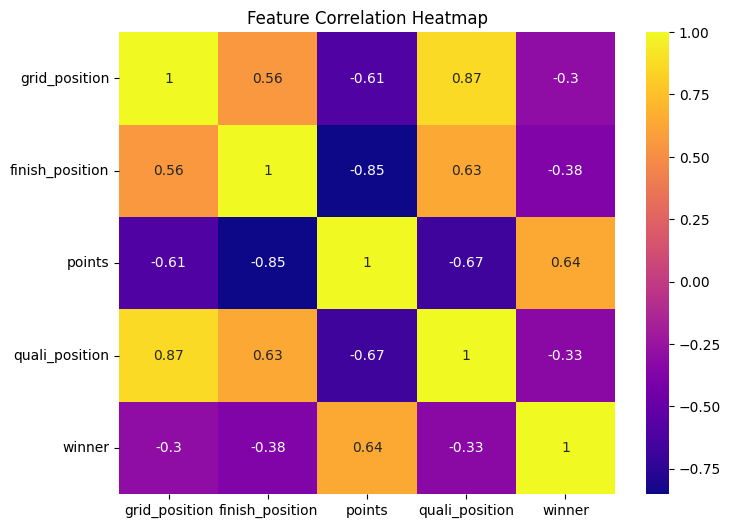

In [9]:
numeric_cols = ["grid_position", "finish_position", "points", "quali_position", "winner"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap='plasma', annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

### Top Winning Drivers

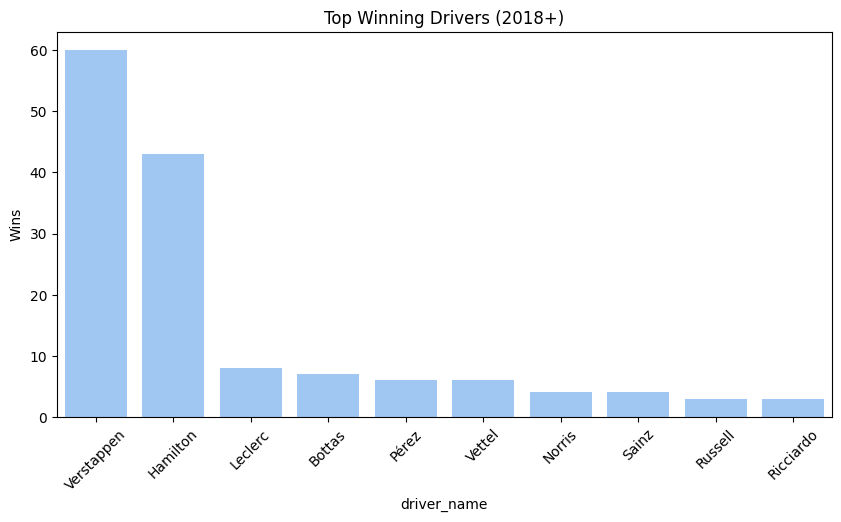

In [10]:
top_drivers = (df[df['winner'] == 1]['driver_name'].value_counts().head(10))

plt.figure(figsize=(10,5))
sns.barplot(x=top_drivers.index, y=top_drivers.values)
plt.title("Top Winning Drivers (2018+)")
plt.ylabel("Wins")
plt.xticks(rotation=45)
plt.show()

### Top Constructors

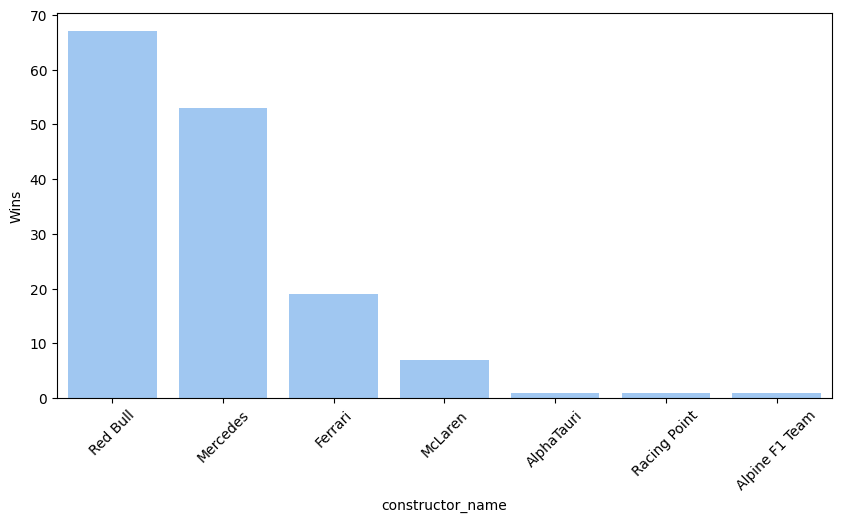

In [11]:
top_constructors = df[df['winner'] == 1]['constructor_name'].value_counts()
plt.figure(figsize=(10,5))
sns.barplot(x=top_constructors.index, y=top_constructors.values)
plt.ylabel("Wins")
plt.xticks(rotation=45)
plt.show()

### Drivers Consistency

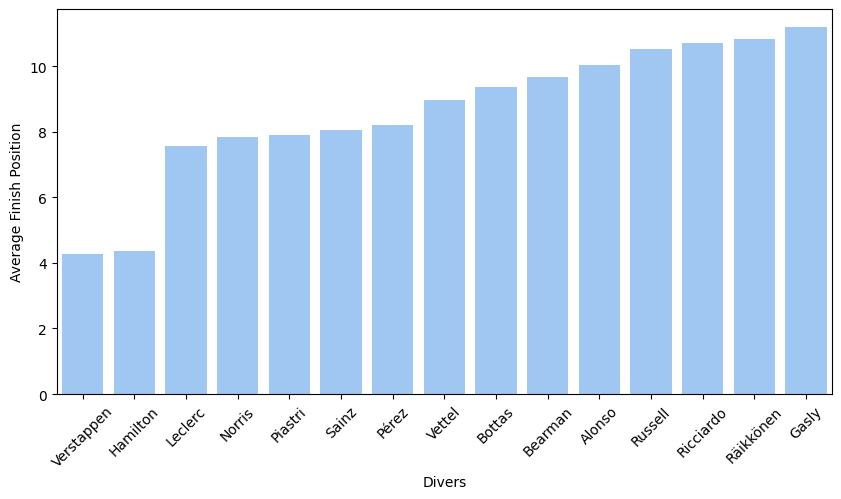

In [12]:
divers_consistency = df.groupby('driver_name')['finish_position'].mean().sort_values().head(15)

plt.figure(figsize=(10,5))
sns.barplot(x=divers_consistency.index, y=divers_consistency.values)
plt.xlabel("Divers")
plt.ylabel("Average Finish Position")
plt.xticks(rotation=45)
plt.show()

### DNF Analysis

Approximation:

finish_position > 15 often indicates DNF/problems

In [13]:
df['dnf_flag'] = np.where(df['finish_position'] > 15, 1, 0)
df.sample(10)

,race_id,year,round,race_date,race_name,circuit_id,driver_id,driver_code,driver_name,constructor_id,constructor_name,grid_position,finish_position,points,status_id,quali_position,winner,dnf_flag
2683,1130,2024,10,2024-06-23,Spanish Grand Prix,catalunya,815,perez,Pérez,9,Red Bull,11,8,4.0,1,8.0,0,0
2094,1099,2023,2,2023-03-19,Saudi Arabian Grand Prix,jeddah,822,bottas,Bottas,51,Alfa Romeo,14,18,0.0,11,14.0,0,1
877,1032,2020,2,2020-07-12,Styrian Grand Prix,red_bull_ring,20,vettel,Vettel,6,Ferrari,10,20,0.0,130,10.0,0,1
2829,1137,2024,17,2024-09-15,Azerbaijan Grand Prix,baku,855,zhou,Zhou,15,Sauber,17,14,0.0,1,18.0,0,0
269,1002,2018,14,2018-09-02,Italian Grand Prix,monza,845,sirotkin,Sirotkin,3,Williams,12,10,1.0,11,12.0,0,0
2501,1121,2024,1,2024-03-02,Bahrain Grand Prix,bahrain,847,russell,Russell,131,Mercedes,3,5,10.0,1,3.0,0,0
1732,1079,2022,6,2022-05-22,Spanish Grand Prix,catalunya,849,latifi,Latifi,3,Williams,19,16,0.0,12,20.0,0,1
1666,1076,2022,3,2022-04-10,Australian Grand Prix,albert_park,848,albon,Albon,3,Williams,20,10,1.0,1,16.0,0,0
2563,1124,2024,4,2024-04-07,Japanese Grand Prix,suzuka,857,piastri,Piastri,1,McLaren,6,8,4.0,1,6.0,0,0
1902,1088,2022,15,2022-09-04,Dutch Grand Prix,zandvoort,4,alonso,Alonso,214,Alpine F1 Team,13,6,8.0,1,13.0,0,0


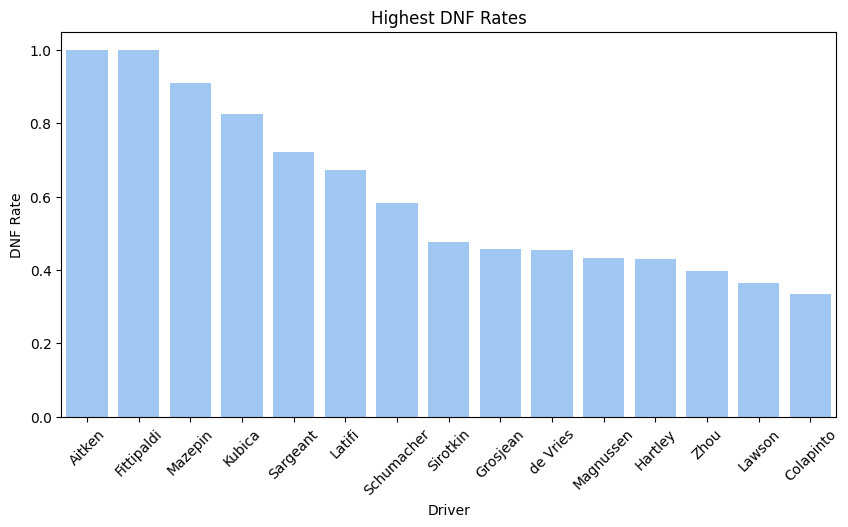

In [14]:
# Drivers with Highest DNF Rate
dnf_rates = df.groupby('driver_name')['dnf_flag'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,5))
sns.barplot(x=dnf_rates.index, y=dnf_rates.values)
plt.title("Highest DNF Rates") 
plt.xlabel("Driver") 
plt.ylabel("DNF Rate")
plt.xticks(rotation=45)
plt.show()

### Circuit Analysis

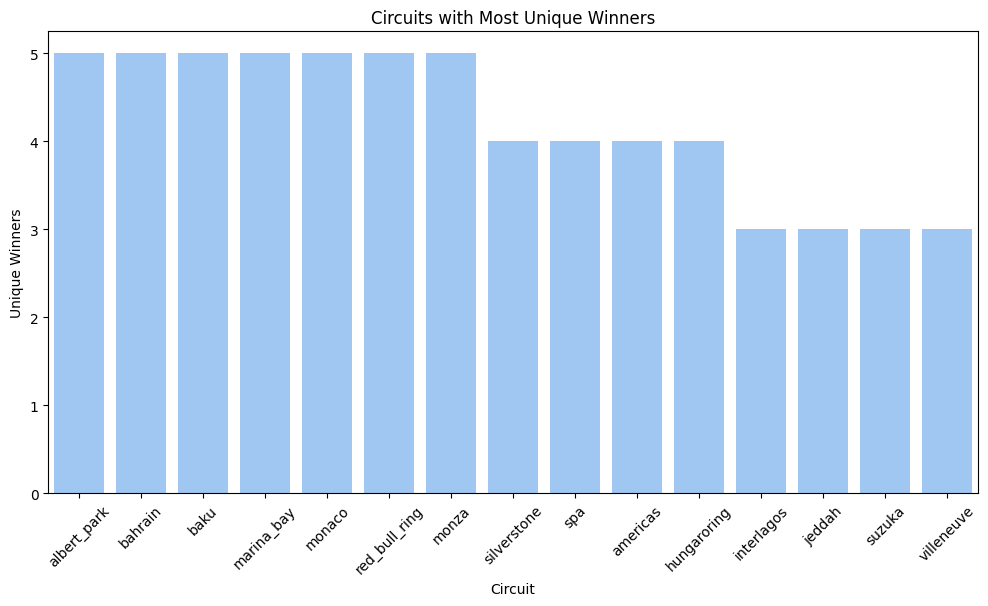

In [15]:
circuit_winners = df[df["winner"] == 1].groupby("circuit_id")["driver_name"].nunique().sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6)) 
sns.barplot(x=circuit_winners.index, y=circuit_winners.values) 
plt.title("Circuits with Most Unique Winners") 
plt.xlabel("Circuit") 
plt.ylabel("Unique Winners") 
plt.xticks(rotation=45) 
plt.show()

### Finish Position Distribution

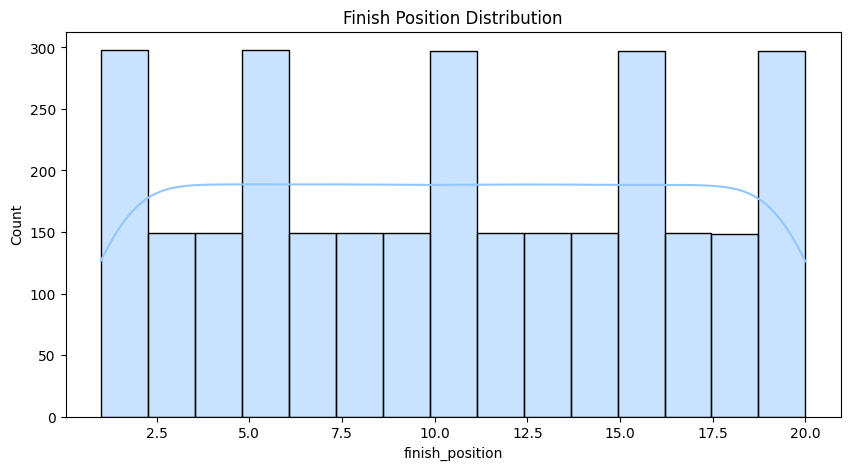

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(df['finish_position'], bins=15, kde=True)
plt.title("Finish Position Distribution")
plt.show()

### Grid vs Finish Scatter Plot

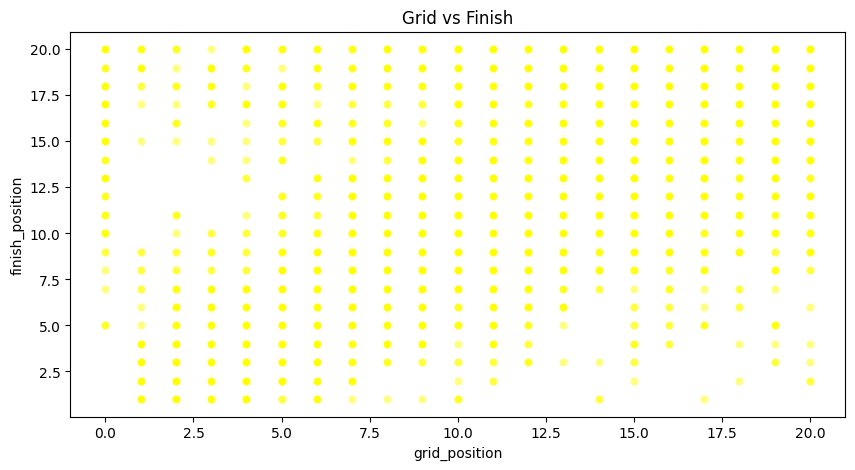

In [17]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='grid_position', y='finish_position', color='yellow', alpha=0.5)
plt.title("Grid vs Finish")
plt.show()

### Season Dominance Trends

In [18]:
yearly_constructor_wins = df[df["winner"] == 1].groupby(["year", "constructor_name"]).size().reset_index(name="wins")
yearly_constructor_wins.head()

,year,constructor_name,wins
0,2018,Ferrari,6
1,2018,Mercedes,11
2,2018,Red Bull,4
3,2019,Ferrari,3
4,2019,Mercedes,15


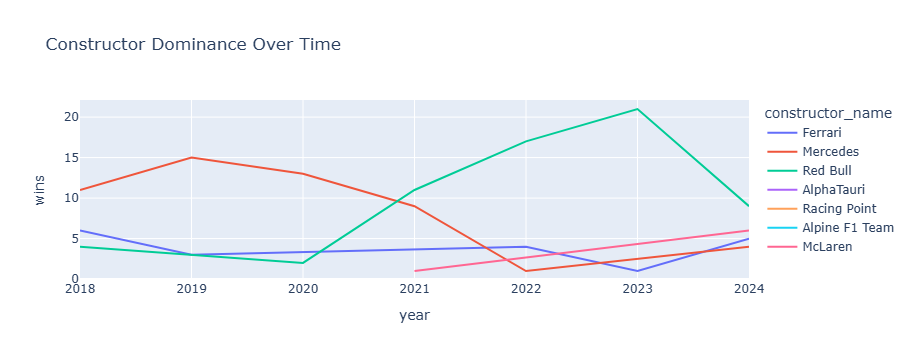

In [19]:
# Interactive Plot
fig = px.line( yearly_constructor_wins, 
               x="year", 
               y="wins", 
               color="constructor_name", 
               title="Constructor Dominance Over Time" 
             ) 
fig.show()

### Qualifying Importance

In [20]:
quali_winners = df[df['winner'] == 1]['quali_position'].value_counts().sort_index()
quali_winners.head()

quali_position
1.0    77
2.0    31
3.0    20
4.0     7
5.0     4
Name: count, dtype: int64

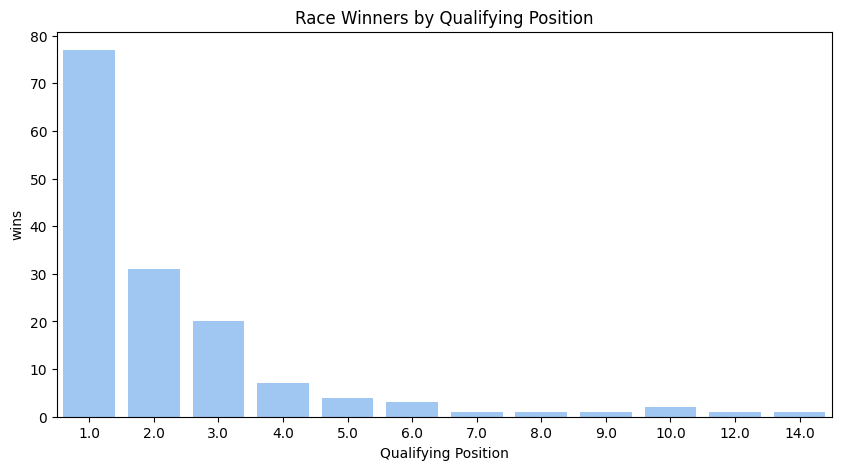

In [21]:
plt.figure(figsize=(10,5))
sns.barplot(x=quali_winners.index, y=quali_winners.values)
plt.title("Race Winners by Qualifying Position")
plt.xlabel("Qualifying Position")
plt.ylabel("wins")
plt.show()

KEY INSIGHTS FROM EDA
---------------------

1. Grid position strongly impacts race outcome
2. Pole position converts to wins very frequently
3. Certain constructors dominate regulation eras
4. Reliability (DNFs) matters heavily
5. Some circuits are less predictable than others
6. Qualifying performance is highly correlated with race wins
7. Finish position and grid position are strongly correlated


In [22]:
df.to_csv("../data/processed/f1_eda_ready.csv", index=False) 
print("EDA-ready dataset saved.")

EDA-ready dataset saved.
